# Implementing the workflow step-by-step

## Camera Properties and Geometry Estimation

In [1]:
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image, ImageDraw

# Verify SIFT availability (requires opencv-python >= 4.4 or opencv-contrib-python)
try:
    _sift_test = cv2.SIFT_create()
    print(f"OpenCV {cv2.__version__} — SIFT: available")
except AttributeError:
    raise RuntimeError("SIFT not found. Install: pip install opencv-contrib-python")

print(f"NumPy  {np.__version__}")


OpenCV 4.13.0 — SIFT: available
NumPy  2.4.6


### Step 1 — Generate the Calibration Plate

A 130 mm × 130 mm pseudo-random binary pattern (seed-deterministic) is generated at 300 DPI.
This is the same plate that is physically printed and placed in the scene.


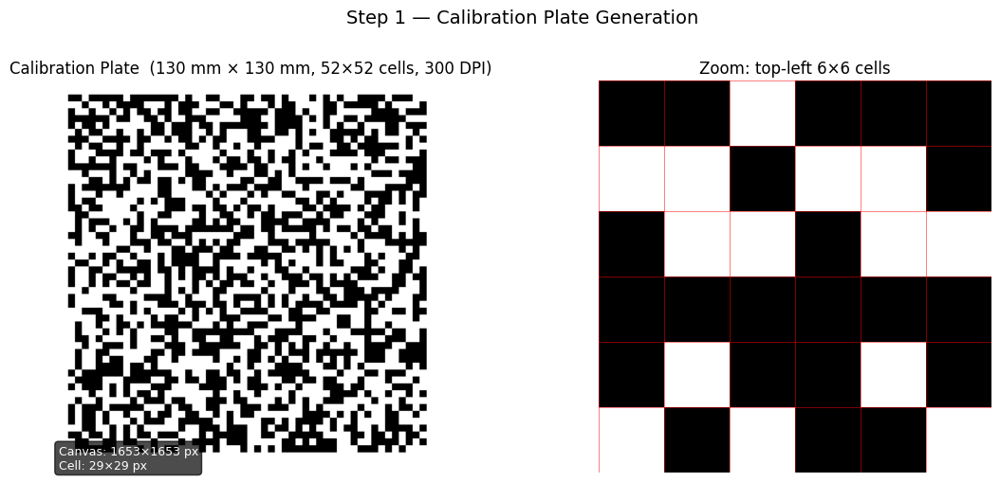

Canvas : 1653 × 1653 px
Cell   : 29 × 29 px  (2.50 mm per cell)
Cells  : 52 × 52 = 2704 total


In [2]:
# ── Physical / print parameters (must match generate_pattern.py) ──────────────
PATTERN_SIZE_MM = 130
DPI             = 300
GRID_CELLS      = 52
SEED            = 42
BORDER_MM       = 5
MM_PER_INCH     = 25.4

pattern_px  = int((PATTERN_SIZE_MM / MM_PER_INCH) * DPI)   # pattern region in pixels
border_px   = int((BORDER_MM       / MM_PER_INCH) * DPI)   # white border in pixels
canvas_px   = pattern_px + 2 * border_px                    # total canvas size
cell_px     = pattern_px // GRID_CELLS                      # one cell side in pixels
HALF_PLATE  = PATTERN_SIZE_MM / 2.0                         # 65 mm, used later

# ── Generate pattern ──────────────────────────────────────────────────────────
img_pil = Image.new("L", (canvas_px, canvas_px), 255)
draw    = ImageDraw.Draw(img_pil)
random.seed(SEED)
for row in range(GRID_CELLS):
    for col in range(GRID_CELLS):
        value = random.choice([0, 255])
        x0 = border_px + col * cell_px
        y0 = border_px + row * cell_px
        draw.rectangle([x0, y0, x0 + cell_px, y0 + cell_px], fill=value)

plate_img = np.array(img_pil)   # grayscale uint8 numpy array (H, W)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Full plate
axes[0].imshow(plate_img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(
    f"Calibration Plate  ({PATTERN_SIZE_MM} mm × {PATTERN_SIZE_MM} mm, "
    f"{GRID_CELLS}×{GRID_CELLS} cells, {DPI} DPI)"
)
axes[0].axis("off")
# Annotate canvas metrics
axes[0].text(
    0.01, 0.01,
    f"Canvas: {canvas_px}×{canvas_px} px\nCell: {cell_px}×{cell_px} px",
    transform=axes[0].transAxes, fontsize=9, color="white",
    bbox=dict(boxstyle="round", facecolor="black", alpha=0.7),
)

# Zoom into a 6×6 cell region to show binary pattern
zoom_cells  = 6
zoom_px     = zoom_cells * cell_px
roi         = plate_img[border_px : border_px + zoom_px,
                         border_px : border_px + zoom_px]
axes[1].imshow(roi, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[1].set_title(f"Zoom: top-left {zoom_cells}×{zoom_cells} cells")
axes[1].axis("off")
# Draw cell grid
for k in range(zoom_cells + 1):
    axes[1].axhline(k * cell_px - 0.5, color="red", linewidth=0.6, alpha=0.6)
    axes[1].axvline(k * cell_px - 0.5, color="red", linewidth=0.6, alpha=0.6)

plt.suptitle("Step 1 — Calibration Plate Generation", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Canvas : {canvas_px} × {canvas_px} px")
print(f"Cell   : {cell_px} × {cell_px} px  ({PATTERN_SIZE_MM/GRID_CELLS:.2f} mm per cell)")
print(f"Cells  : {GRID_CELLS} × {GRID_CELLS} = {GRID_CELLS**2} total")


### Step 2 — Camera Geometry: Define 12 Virtual Viewpoints

Twelve synthetic cameras are placed at **45° elevation** around the plate at **30° azimuth intervals**
(0°, 30°, …, 330°). Each camera looks at the plate origin. Their exact world positions are known,
which is what ultimately supplies the metric scale to the bundle adjustment.


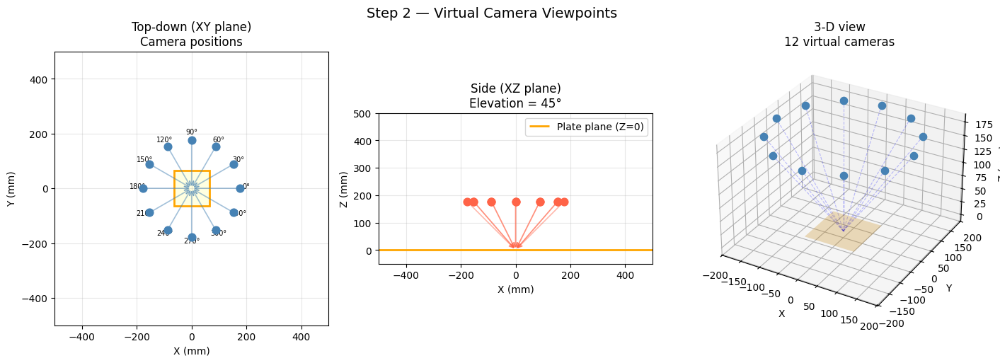

   Az     cam_x     cam_y     cam_z  mm
    0°     176.8       0.0     176.8
   30°     153.1      88.4     176.8
   60°      88.4     153.1     176.8
   90°       0.0     176.8     176.8
  120°     -88.4     153.1     176.8
  150°    -153.1      88.4     176.8
  180°    -176.8       0.0     176.8
  210°    -153.1     -88.4     176.8
  240°     -88.4    -153.1     176.8
  270°      -0.0    -176.8     176.8
  300°      88.4    -153.1     176.8
  330°     153.1     -88.4     176.8


In [23]:
# ── Scene parameters ──────────────────────────────────────────────────────────
CAMERA_DIST_MM = 250.0   # camera distance from plate centre (mm)
ELEVATION_DEG  = 45.0
AZIMUTHS_DEG   = np.arange(0, 360, 30)   # 12 azimuths


def camera_pose(azimuth_deg: float, elevation_deg: float, distance: float):
    """
    Return (R, t, cam_pos_world) for a camera at the given spherical position
    looking at the world origin.

    Convention (OpenCV): X = right, Y = down, Z = forward.
    A world point X_w maps to camera frame as: X_c = R @ X_w + t
    """
    az = np.radians(azimuth_deg)
    el = np.radians(elevation_deg)

    cam_pos = np.array([
        distance * np.cos(el) * np.cos(az),
        distance * np.cos(el) * np.sin(az),
        distance * np.sin(el),
    ])

    # Camera Z-axis: pointing from camera toward origin
    z_cam = -cam_pos / np.linalg.norm(cam_pos)

    # Camera X-axis: right = forward × world_up  (world_up = Z)
    world_up = np.array([0.0, 0.0, 1.0])
    x_cam = np.cross(z_cam, world_up)
    x_cam /= np.linalg.norm(x_cam)

    # Camera Y-axis: down = forward × right
    y_cam = np.cross(z_cam, x_cam)
    y_cam /= np.linalg.norm(y_cam)

    R = np.array([x_cam, y_cam, z_cam])   # rows = camera axes in world
    t = -R @ cam_pos                       # translation in camera frame
    return R, t, cam_pos


# Compute all 12 poses
camera_poses = [
    dict(zip(("az", "R", "t", "pos"), (az, *camera_pose(az, ELEVATION_DEG, CAMERA_DIST_MM))))
    for az in AZIMUTHS_DEG
]

# ── Visualise ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))

# — Top-down (XY) view —
ax1 = fig.add_subplot(131)
plate_rect = mpatches.FancyBboxPatch(
    (-HALF_PLATE, -HALF_PLATE), PATTERN_SIZE_MM, PATTERN_SIZE_MM,
    boxstyle="square,pad=0", linewidth=2, edgecolor="orange", facecolor="lightyellow",
)
ax1.add_patch(plate_rect)
for cp in camera_poses:
    px, py = cp["pos"][:2]
    ax1.annotate("", xy=(0, 0), xytext=(px, py),
                 arrowprops=dict(arrowstyle="->", color="steelblue", alpha=0.5, lw=1.2))
    ax1.scatter(px, py, s=60, color="steelblue", zorder=4)
    ax1.text(px * 1.12, py * 1.12, f"{int(cp['az'])}°", fontsize=7, ha="center")
ax1.set_aspect("equal"); ax1.set_xlim(-500, 500); ax1.set_ylim(-500, 500)
ax1.set_xlabel("X (mm)"); ax1.set_ylabel("Y (mm)")
ax1.set_title("Top-down (XY plane)\nCamera positions"); ax1.grid(alpha=0.3)

# — Side (XZ) view —
ax2 = fig.add_subplot(132)
ax2.hlines(0, -500, 500, colors="orange", linewidths=2, label="Plate plane (Z=0)")
for cp in camera_poses:
    px, pz = cp["pos"][0], cp["pos"][2]
    ax2.annotate("", xy=(0, 0), xytext=(px, pz),
                 arrowprops=dict(arrowstyle="->", color="tomato", alpha=0.45, lw=1.2))
    ax2.scatter(px, pz, s=60, color="tomato", zorder=4)
ax2.set_aspect("equal"); ax2.set_xlim(-500, 500); ax2.set_ylim(-50, 500)
ax2.set_xlabel("X (mm)"); ax2.set_ylabel("Z (mm)")
ax2.set_title("Side (XZ plane)\nElevation = 45°"); ax2.legend(); ax2.grid(alpha=0.3)

# — 3-D view —
ax3 = fig.add_subplot(133, projection="3d")
xx, yy = np.meshgrid([-HALF_PLATE, HALF_PLATE], [-HALF_PLATE, HALF_PLATE])
ax3.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.25, color="orange")
for cp in camera_poses:
    p = cp["pos"]
    ax3.scatter(*p, s=55, color="steelblue")
    ax3.plot([p[0], 0], [p[1], 0], [p[2], 0], "b--", alpha=0.25, lw=0.8)
ax3.set_xlabel("X"); ax3.set_ylabel("Y"); ax3.set_zlabel("Z (mm)")
ax3.set_title("3-D view\n12 virtual cameras"); ax3.set_box_aspect([1, 1, 0.7])

plt.suptitle("Step 2 — Virtual Camera Viewpoints", fontsize=14)
plt.tight_layout()
plt.show()

print(f"{'Az':>5}  {'cam_x':>8}  {'cam_y':>8}  {'cam_z':>8}  mm")
for cp in camera_poses:
    p = cp["pos"]
    print(f"{int(cp['az']):>5}°  {p[0]:>8.1f}  {p[1]:>8.1f}  {p[2]:>8.1f}")


### Step 3 — Render Virtual Reference Photographs

Each virtual camera position yields one *synthetic photograph* of the calibration plate by computing
the perspective homography that maps the flat plate image to the camera's image plane.  
The four physical corners of the plate serve as the reference quadrilateral for `warpPerspective`.


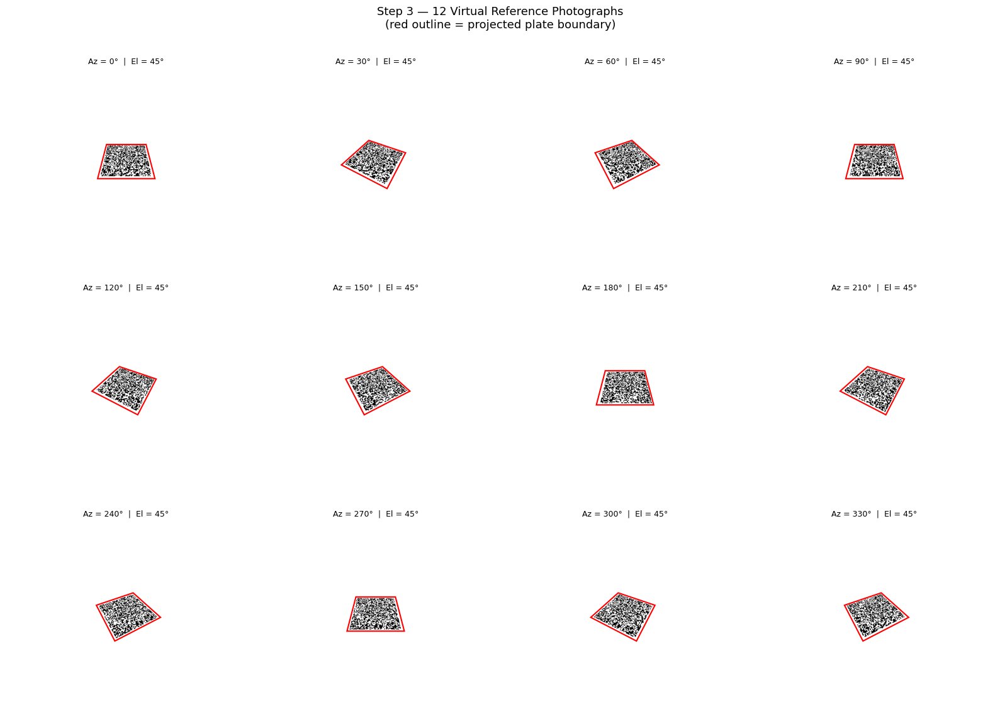

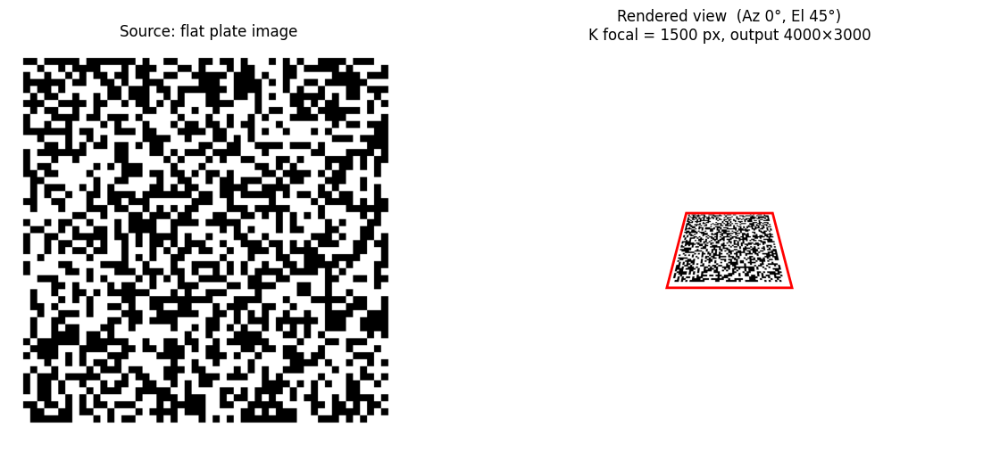

Intrinsic matrix K:
[[1.5e+03 0.0e+00 2.0e+03]
 [0.0e+00 1.5e+03 1.5e+03]
 [0.0e+00 0.0e+00 1.0e+00]]

Rendered 12 virtual images  (4000×3000 px each)


In [25]:
# ── Synthetic camera intrinsics ───────────────────────────────────────────────
OUT_W, OUT_H = 4000, 3000
FOCAL_PX     = 1500.0             # focal length in pixels (chosen to frame plate ~60% of image)
CX, CY       = OUT_W / 2.0, OUT_H / 2.0

K = np.array([
    [FOCAL_PX,       0,  CX],
    [      0,  FOCAL_PX,  CY],
    [      0,        0,    1],
], dtype=np.float64)

# Plate corners in 3-D world (mm) and corresponding source pixel corners
# (0,0)→(-half,-half,0), (W,0)→(+half,-half,0), (W,H)→(+half,+half,0), (0,H)→(-half,+half,0)
plate_corners_3d = np.array([
    [-HALF_PLATE, -HALF_PLATE, 0],
    [ HALF_PLATE, -HALF_PLATE, 0],
    [ HALF_PLATE,  HALF_PLATE, 0],
    [-HALF_PLATE,  HALF_PLATE, 0],
], dtype=np.float64)

H_src, W_src = plate_img.shape
src_corners = np.array(
    [[0, 0], [W_src, 0], [W_src, H_src], [0, H_src]], dtype=np.float32
)
dist_zeros = np.zeros(5)


def render_view(plate_gray, R, t):
    """Project plate_gray to a virtual photo using the given camera pose."""
    rvec, _ = cv2.Rodrigues(R)
    img_corners, _ = cv2.projectPoints(
        plate_corners_3d.reshape(-1, 1, 3), rvec, t, K, dist_zeros
    )
    img_corners = img_corners.reshape(-1, 2).astype(np.float32)

    H_mat, _ = cv2.findHomography(src_corners, img_corners)
    rendered = cv2.warpPerspective(
        plate_gray, H_mat, (OUT_W, OUT_H),
        borderMode=cv2.BORDER_CONSTANT, borderValue=255,
    )
    return rendered, img_corners


# Render all 12 views
virtual_images  = []
virtual_corners = []   # projected plate corners per view (for overlay)
for cp in camera_poses:
    img_v, corners = render_view(plate_img, cp["R"], cp["t"])
    virtual_images.append(img_v)
    virtual_corners.append(corners)

# ── Visualise all 12 rendered photographs ─────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(virtual_images[i], cmap="gray", vmin=0, vmax=255)
    poly = plt.Polygon(virtual_corners[i], fill=False, edgecolor="red", linewidth=1.5)
    ax.add_patch(poly)
    ax.set_title(f"Az = {int(camera_poses[i]['az'])}°  |  El = {int(ELEVATION_DEG)}°", fontsize=9)
    ax.axis("off")

plt.suptitle(
    "Step 3 — 12 Virtual Reference Photographs\n"
    "(red outline = projected plate boundary)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

# ── Side-by-side: source plate vs. one rendered view ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(plate_img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Source: flat plate image"); axes[0].axis("off")

axes[1].imshow(virtual_images[0], cmap="gray", vmin=0, vmax=255)
poly = plt.Polygon(virtual_corners[0], fill=False, edgecolor="red", linewidth=2)
axes[1].add_patch(poly)
axes[1].set_title(f"Rendered view  (Az 0°, El 45°)\n"
                  f"K focal = {FOCAL_PX:.0f} px, output {OUT_W}×{OUT_H}")
axes[1].axis("off")

plt.tight_layout(); plt.show()

print(f"Intrinsic matrix K:\n{K}\n")
print(f"Rendered {len(virtual_images)} virtual images  ({OUT_W}×{OUT_H} px each)")


### Step 4 — SIFT Feature Extraction

Scale-Invariant Feature Transform (SIFT) keypoints and descriptors are extracted from every virtual
image *before* the real photographs are processed.  Rich keypoints are drawn with their orientation
and scale circle for visual inspection.


SIFT keypoints per virtual image:
  Az   0°  2567  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Az  30°  2748  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Az  60°  2708  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Az  90°  2533  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Az 120°  2778  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Az 150°  2760  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Az 180°  2602  ███████████████████████████████████████

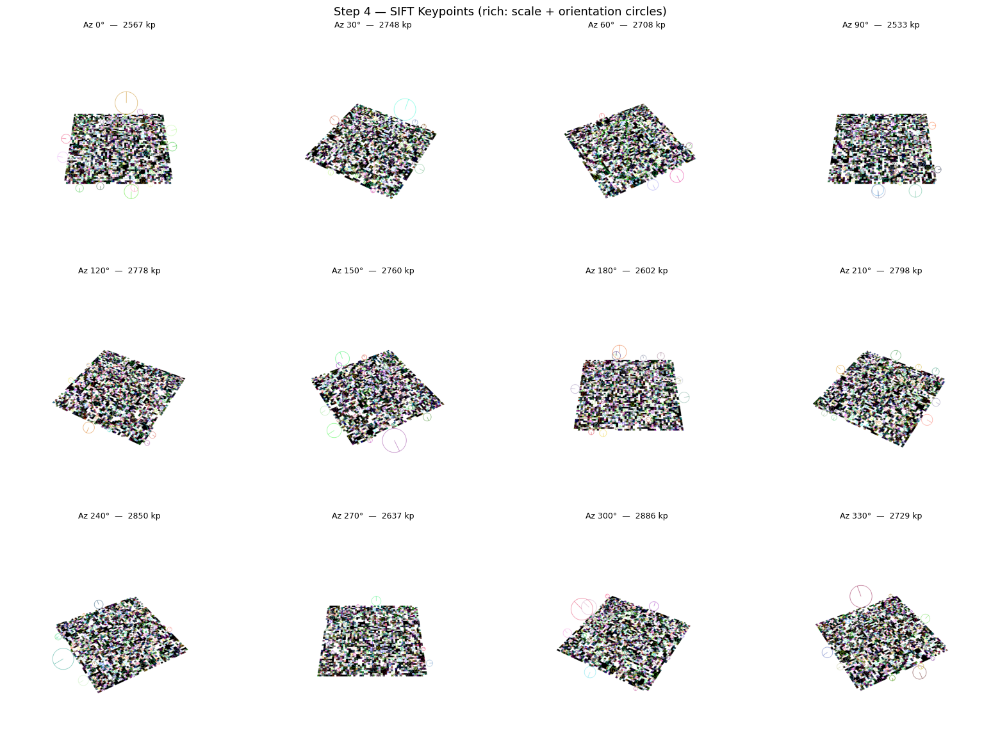

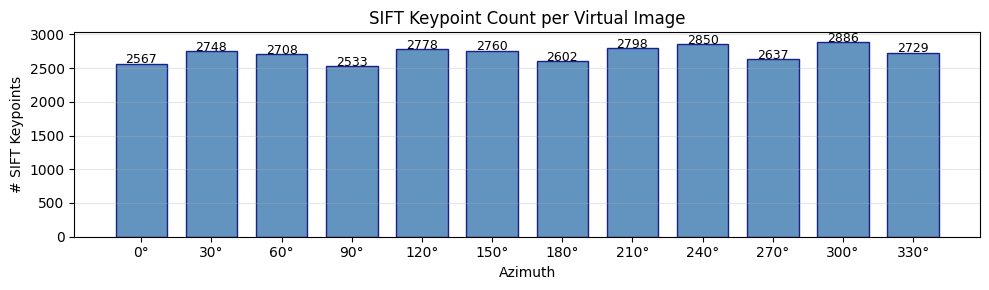

In [5]:
sift = cv2.SIFT_create(
    nfeatures=0,           # detect all features (no cap)
    nOctaveLayers=3,
    contrastThreshold=0.04,
    edgeThreshold=10,
    sigma=1.6,
)

kps_all   = []
descs_all = []
for img_v in virtual_images:
    kp, desc = sift.detectAndCompute(img_v, None)
    kps_all.append(kp)
    descs_all.append(desc)

# ── Keypoint count table ──────────────────────────────────────────────────────
kp_counts = [len(k) for k in kps_all]
print("SIFT keypoints per virtual image:")
for cp, n in zip(camera_poses, kp_counts):
    bar = "█" * (n // 20)
    print(f"  Az {int(cp['az']):3d}°  {n:4d}  {bar}")
print(f"\n  Mean : {np.mean(kp_counts):.0f}")
print(f"  Min  : {min(kp_counts)}")
print(f"  Max  : {max(kp_counts)}")

# ── Draw rich keypoints on every image ───────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, ax in enumerate(axes.ravel()):
    img_kp = cv2.drawKeypoints(
        virtual_images[i], kps_all[i], None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    ax.imshow(img_kp)
    ax.set_title(f"Az {int(camera_poses[i]['az'])}°  —  {kp_counts[i]} kp", fontsize=9)
    ax.axis("off")

plt.suptitle("Step 4 — SIFT Keypoints (rich: scale + orientation circles)", fontsize=13)
plt.tight_layout(); plt.show()

# ── Keypoint count bar chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
bars = ax.bar(AZIMUTHS_DEG, kp_counts, width=22,
              color="steelblue", edgecolor="navy", alpha=0.85)
for bar, n in zip(bars, kp_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(n), ha="center", fontsize=9)
ax.set_xticks(AZIMUTHS_DEG)
ax.set_xticklabels([f"{int(a)}°" for a in AZIMUTHS_DEG])
ax.set_xlabel("Azimuth"); ax.set_ylabel("# SIFT Keypoints")
ax.set_title("SIFT Keypoint Count per Virtual Image")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


### Step 5 — SIFT Feature Matching

Lowe's ratio test (threshold 0.75) filters putative BFMatcher matches between every consecutive pair
of virtual images (circular: 330° ↔ 0°).  The match count and spatial distribution are visualised.


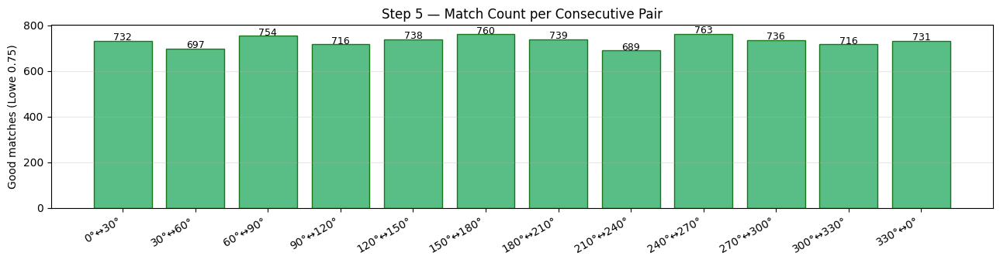

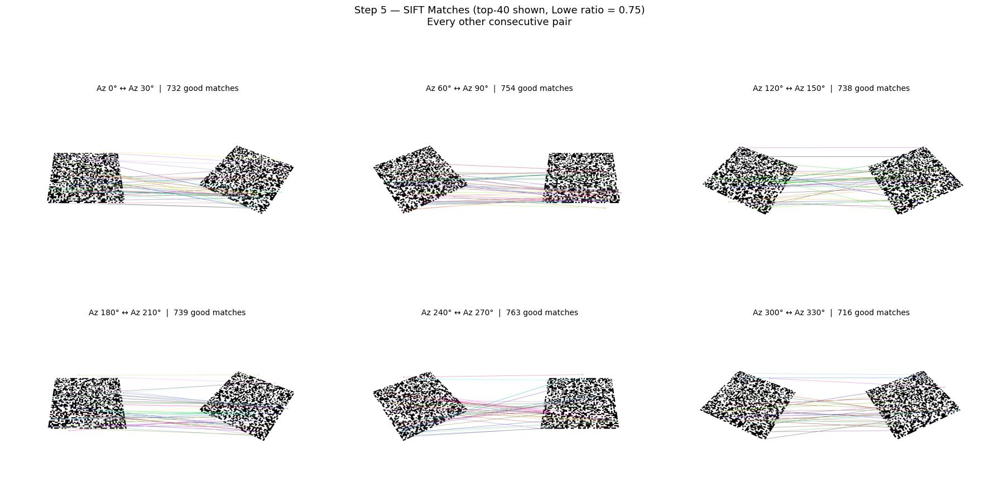

Total good matches across all pairs: 8771
Mean per pair: 731   Min: 689   Max: 763


In [6]:
RATIO_THRESH = 0.75
bf = cv2.BFMatcher(cv2.NORM_L2)

def lowe_match(desc1, desc2, ratio=RATIO_THRESH):
    """Return good matches after Lowe's ratio test."""
    if desc1 is None or desc2 is None:
        return []
    raw = bf.knnMatch(desc1, desc2, k=2)
    return [m for m, n in raw if m.distance < ratio * n.distance]

# Match every consecutive pair (circular)
n_views = len(virtual_images)
match_pairs = []
for i in range(n_views):
    j = (i + 1) % n_views
    good = lowe_match(descs_all[i], descs_all[j])
    match_pairs.append(dict(i=i, j=j,
                            az_i=int(camera_poses[i]["az"]),
                            az_j=int(camera_poses[j]["az"]),
                            matches=good))

# ── Match count bar chart ─────────────────────────────────────────────────────
match_counts = [len(mp["matches"]) for mp in match_pairs]
pair_labels  = [f"{mp['az_i']}°↔{mp['az_j']}°" for mp in match_pairs]

fig, ax = plt.subplots(figsize=(13, 3.5))
bars = ax.bar(range(n_views), match_counts,
              color="mediumseagreen", edgecolor="darkgreen", alpha=0.85)
for bar, n in zip(bars, match_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(n), ha="center", fontsize=9)
ax.set_xticks(range(n_views)); ax.set_xticklabels(pair_labels, rotation=30, ha="right")
ax.set_ylabel("Good matches (Lowe 0.75)"); ax.set_title("Step 5 — Match Count per Consecutive Pair")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

# ── Draw matches for 6 selected pairs ────────────────────────────────────────
selected_pairs = [0, 2, 4, 6, 8, 10]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, pair_idx in zip(axes.ravel(), selected_pairs):
    mp = match_pairs[pair_idx]
    top40 = sorted(mp["matches"], key=lambda m: m.distance)[:40]
    match_img = cv2.drawMatches(
        virtual_images[mp["i"]], kps_all[mp["i"]],
        virtual_images[mp["j"]], kps_all[mp["j"]],
        top40, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    ax.imshow(match_img)
    ax.set_title(
        f"Az {mp['az_i']}° ↔ Az {mp['az_j']}°  |  {len(mp['matches'])} good matches",
        fontsize=10,
    )
    ax.axis("off")

plt.suptitle(
    "Step 5 — SIFT Matches (top-40 shown, Lowe ratio = 0.75)\n"
    "Every other consecutive pair",
    fontsize=13,
)
plt.tight_layout(); plt.show()
print(f"Total good matches across all pairs: {sum(match_counts)}")
print(f"Mean per pair: {np.mean(match_counts):.0f}   Min: {min(match_counts)}   Max: {max(match_counts)}")


### Step 6 — Essential Matrix, RANSAC & Geometric Verification

For each consecutive pair we estimate the essential matrix $E$ using RANSAC, decompose it into a
relative rotation $R_{rel}$ and unit translation $t_{rel}$, and compare the recovered rotation angle
with the known ground-truth.  Inlier / outlier matches are colour-coded.


Pair             GT Δaz   Est. R°     GT R°   ΔR err°   Inliers   Outliers
────────────────────────────────────────────────────────────────────────
    0°↔ 30°      30.0°     29.35°     30.00°      2.14°       615        117
   30°↔ 60°      30.0°     32.89°     30.00°      3.98°       486        211
   60°↔ 90°      30.0°     41.60°     30.00°     29.09°       242        512
   90°↔120°      30.0°     41.12°     30.00°     28.69°       318        398
  120°↔150°      30.0°     41.26°     30.00°     28.82°       254        484
  150°↔180°      30.0°     30.76°     30.00°      2.08°       597        163
  180°↔210°      30.0°     41.43°     30.00°     28.94°       266        473
  210°↔240°      30.0°     41.22°     30.00°     28.55°       441        248
  240°↔270°      30.0°     41.66°     30.00°     29.11°       235        528
  270°↔300°      30.0°     31.10°     30.00°      1.65°       585        151
  300°↔330°      30.0°     41.41°     30.00°     28.91°       293        423
  330

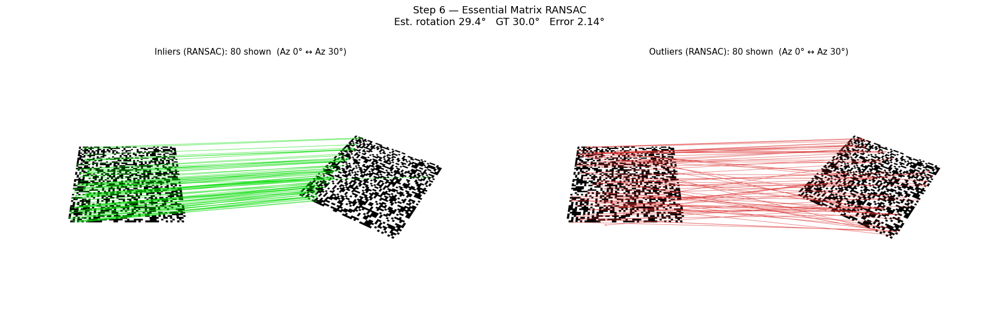

In [7]:
def rot_angle_deg(R):
    """Rotation angle of matrix R in degrees."""
    return np.degrees(np.arccos(np.clip((np.trace(R) - 1) / 2, -1.0, 1.0)))

def estimate_pose_from_matches(kp1, kp2, good_matches):
    """
    Estimate essential matrix via RANSAC and recover relative pose.
    Returns (R_rel, t_rel, inlier_mask_bool) or None on failure.
    """
    if len(good_matches) < 8:
        return None
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])
    E, mask_E = cv2.findEssentialMat(pts1, pts2, K,
                                      method=cv2.RANSAC, prob=0.999, threshold=1.0)
    if E is None:
        return None
    _, R_rel, t_rel, mask_pose = cv2.recoverPose(E, pts1, pts2, K, mask=mask_E)
    return R_rel, t_rel.ravel(), mask_pose.ravel().astype(bool)

# ── Run for all pairs ─────────────────────────────────────────────────────────
print(f"{'Pair':<14}  {'GT Δaz':>7}  {'Est. R°':>8}  {'GT R°':>8}  "
      f"{'ΔR err°':>8}  {'Inliers':>8}  {'Outliers':>9}")
print("─" * 72)

pose_results = []
for mp in match_pairs:
    i, j = mp["i"], mp["j"]
    result = estimate_pose_from_matches(kps_all[i], kps_all[j], mp["matches"])

    # Ground-truth relative rotation R_j @ R_i^T
    R_gt = camera_poses[j]["R"] @ camera_poses[i]["R"].T
    gt_angle = rot_angle_deg(R_gt)

    if result is None:
        print(f"  {mp['az_i']:3d}°↔{mp['az_j']:3d}°   insufficient matches")
        pose_results.append(None)
        continue

    R_rel, t_rel, inliers = result
    est_angle = rot_angle_deg(R_rel)

    # Angular error between estimated and ground-truth relative rotation
    R_err = R_rel @ R_gt.T
    err_deg = rot_angle_deg(R_err)

    n_in  = int(inliers.sum())
    n_out = len(mp["matches"]) - n_in
    print(f"  {mp['az_i']:3d}°↔{mp['az_j']:3d}°   "
          f"{30:>7.1f}°  {est_angle:>8.2f}°  {gt_angle:>8.2f}°  "
          f"{err_deg:>8.2f}°  {n_in:>8d}  {n_out:>9d}")
    pose_results.append(dict(R=R_rel, t=t_rel, inliers=inliers,
                              est_angle=est_angle, gt_angle=gt_angle, err=err_deg))

# ── Inlier / outlier visualisation for the first pair ────────────────────────
mp = match_pairs[0]
res = pose_results[0]
i, j = mp["i"], mp["j"]

inlier_m  = [m for m, ok in zip(mp["matches"], res["inliers"]) if ok]
outlier_m = [m for m, ok in zip(mp["matches"], res["inliers"]) if not ok]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, matches_sub, color, label in [
    (axes[0], inlier_m[:80],  (0, 220, 0),  "Inliers (RANSAC)"),
    (axes[1], outlier_m[:80], (220, 50, 50), "Outliers (RANSAC)"),
]:
    img_drawn = cv2.drawMatches(
        virtual_images[i], kps_all[i],
        virtual_images[j], kps_all[j],
        matches_sub, None,
        matchColor=color,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    ax.imshow(img_drawn)
    ax.set_title(
        f"{label}: {len(matches_sub)} shown  "
        f"(Az {mp['az_i']}° ↔ Az {mp['az_j']}°)",
        fontsize=11,
    )
    ax.axis("off")

plt.suptitle(
    f"Step 6 — Essential Matrix RANSAC\n"
    f"Est. rotation {res['est_angle']:.1f}°   GT {res['gt_angle']:.1f}°   Error {res['err']:.2f}°",
    fontsize=13,
)
plt.tight_layout(); plt.show()


### Step 7 — Triangulation & 3-D Point Cloud

Matched feature points are triangulated using the ground-truth projection matrices.  Because all
points lie on the plate plane ($Z=0$), the recovered Z-distribution serves as a geometric sanity
check: a sharp peak near $Z=0$ confirms consistent camera geometry and correct matching.


Total triangulated : 4929
Valid (near Z=0)   : 4922  (99.9%)


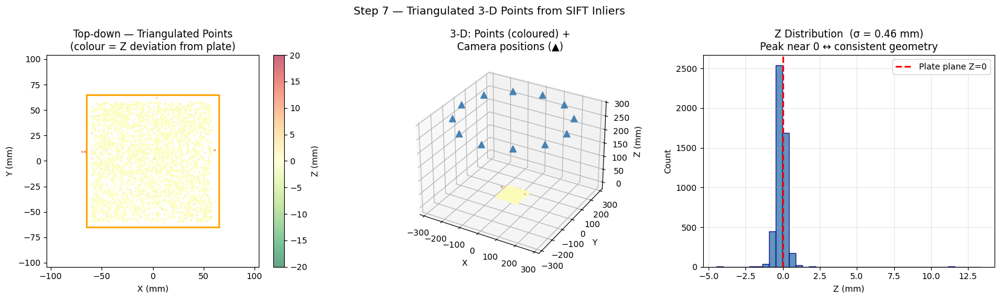

In [8]:
def triangulate_pair(kp1, kp2, matches, R1, t1, R2, t2):
    """
    Triangulate 3-D points from a matched pair using ground-truth poses.
    Returns (N, 3) array in world coordinates.
    """
    P1 = K @ np.hstack([R1, t1.reshape(3, 1)])
    P2 = K @ np.hstack([R2, t2.reshape(3, 1)])
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).T   # 2×N
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).T
    pts4d = cv2.triangulatePoints(P1, P2, pts1, pts2)             # 4×N homogeneous
    pts3d = (pts4d[:3] / pts4d[3]).T                              # N×3
    return pts3d


# Triangulate inlier matches from every pair
all_pts3d = []
for mp, res in zip(match_pairs, pose_results):
    if res is None:
        continue
    i, j = mp["i"], mp["j"]
    inlier_matches = [m for m, ok in zip(mp["matches"], res["inliers"]) if ok]
    pts = triangulate_pair(
        kps_all[i], kps_all[j], inlier_matches,
        camera_poses[i]["R"], camera_poses[i]["t"],
        camera_poses[j]["R"], camera_poses[j]["t"],
    )
    all_pts3d.append(pts)

pts3d_all = np.vstack(all_pts3d)

# Filter: keep points near the plate plane and within plate footprint (× 1.5 margin)
MARGIN = 1.5
mask_valid = (
    (np.abs(pts3d_all[:, 2]) < 30) &
    (np.abs(pts3d_all[:, 0]) < HALF_PLATE * MARGIN) &
    (np.abs(pts3d_all[:, 1]) < HALF_PLATE * MARGIN)
)
pts3d_ok = pts3d_all[mask_valid]
print(f"Total triangulated : {len(pts3d_all)}")
print(f"Valid (near Z=0)   : {len(pts3d_ok)}  ({100*len(pts3d_ok)/len(pts3d_all):.1f}%)")

# ── 3-panel figure ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 5))

# Panel 1 — Top-down XY
ax1 = fig.add_subplot(131)
sc = ax1.scatter(pts3d_ok[:, 0], pts3d_ok[:, 1], c=pts3d_ok[:, 2],
                 cmap="RdYlGn_r", s=3, alpha=0.6, vmin=-20, vmax=20)
plate_rect = mpatches.FancyBboxPatch(
    (-HALF_PLATE, -HALF_PLATE), PATTERN_SIZE_MM, PATTERN_SIZE_MM,
    boxstyle="square,pad=0", linewidth=2, edgecolor="orange", facecolor="none",
)
ax1.add_patch(plate_rect)
plt.colorbar(sc, ax=ax1, label="Z (mm)")
ax1.set_aspect("equal"); ax1.set_xlim(-HALF_PLATE*1.6, HALF_PLATE*1.6)
ax1.set_ylim(-HALF_PLATE*1.6, HALF_PLATE*1.6)
ax1.set_xlabel("X (mm)"); ax1.set_ylabel("Y (mm)")
ax1.set_title("Top-down — Triangulated Points\n(colour = Z deviation from plate)")

# Panel 2 — 3-D scatter
ax2 = fig.add_subplot(132, projection="3d")
ax2.scatter(pts3d_ok[:, 0], pts3d_ok[:, 1], pts3d_ok[:, 2],
            s=2, c=pts3d_ok[:, 2], cmap="RdYlGn_r", alpha=0.4, vmin=-20, vmax=20)
for cp in camera_poses:
    p = cp["pos"]
    ax2.scatter(*p, s=60, color="steelblue", marker="^", zorder=5)
ax2.set_xlabel("X"); ax2.set_ylabel("Y"); ax2.set_zlabel("Z (mm)")
ax2.set_title("3-D: Points (coloured) +\nCamera positions (▲)")

# Panel 3 — Z histogram (flatness check)
ax3 = fig.add_subplot(133)
ax3.hist(pts3d_ok[:, 2], bins=40, color="steelblue", edgecolor="navy", alpha=0.85)
ax3.axvline(0, color="red", linestyle="--", linewidth=2, label="Plate plane Z=0")
z_std = pts3d_ok[:, 2].std()
ax3.set_xlabel("Z (mm)"); ax3.set_ylabel("Count")
ax3.set_title(f"Z Distribution  (σ = {z_std:.2f} mm)\nPeak near 0 ↔ consistent geometry")
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle("Step 7 — Triangulated 3-D Points from SIFT Inliers", fontsize=13)
plt.tight_layout(); plt.show()


### Step 8 — Load Real Photographs

The real images are loaded from `images/set_1/`.  
A contact-sheet is displayed so we can visually verify the plate is visible in every frame.


Loaded 36 real images  (4000×3000 px each)


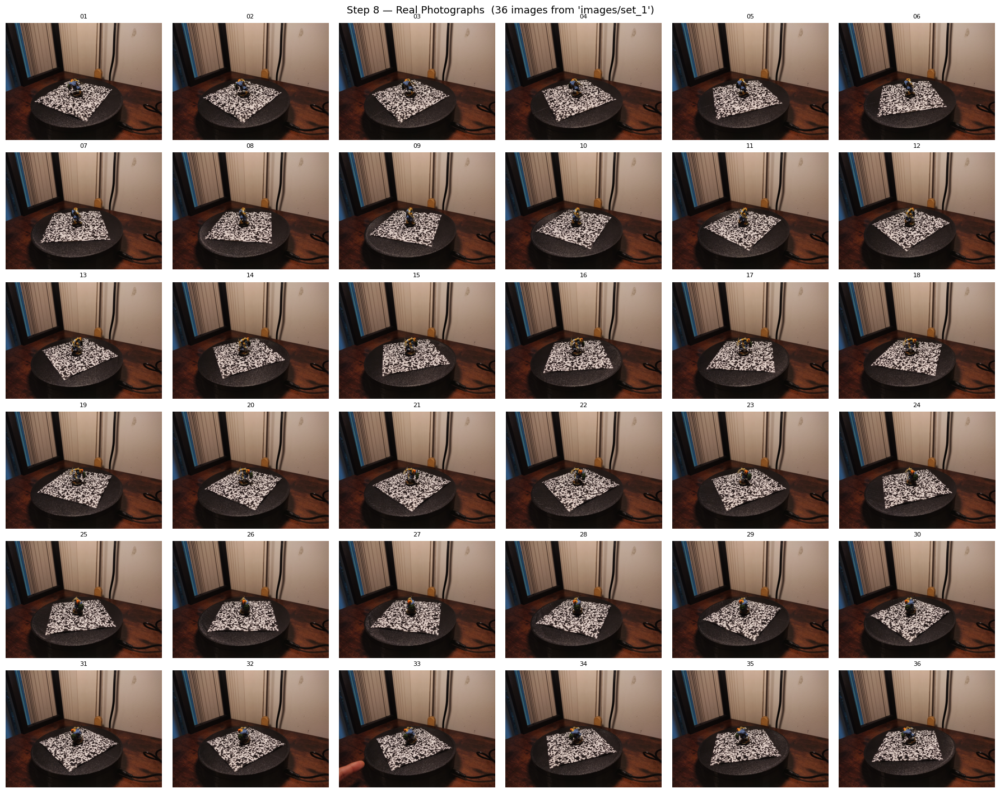

In [17]:
import os, glob

IMAGE_DIR  = r"images/set_1"
img_paths  = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))
assert img_paths, f"No images found in {IMAGE_DIR}"

# Load grayscale for SIFT, keep colour thumbnail for display
real_images_gray = []
real_images_rgb  = []
for p in img_paths:
    bgr = cv2.imread(p)
    real_images_gray.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY))
    real_images_rgb.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

N_REAL = len(real_images_gray)
H_REAL, W_REAL = real_images_gray[0].shape
print(f"Loaded {N_REAL} real images  ({W_REAL}×{H_REAL} px each)")

# ── Contact sheet ─────────────────────────────────────────────────────────────
COLS = 6
ROWS = int(np.ceil(N_REAL / COLS))
fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3, ROWS * 2.4))
axes = np.array(axes).ravel()
for i, ax in enumerate(axes):
    if i < N_REAL:
        ax.imshow(real_images_rgb[i])
        ax.set_title(os.path.basename(img_paths[i]).split("_")[1], fontsize=8)
    ax.axis("off")
plt.suptitle(f"Step 8 — Real Photographs  ({N_REAL} images from '{IMAGE_DIR}')", fontsize=13)
plt.tight_layout(); plt.show()


### Step 9 — SIFT Feature Extraction on Real Images

The same SIFT detector used for the virtual set is applied to each real photograph.
Keypoint density and spatial distribution across the image are shown per frame.


SIFT keypoints per real image — mean: 7305  min: 5755  max: 11621


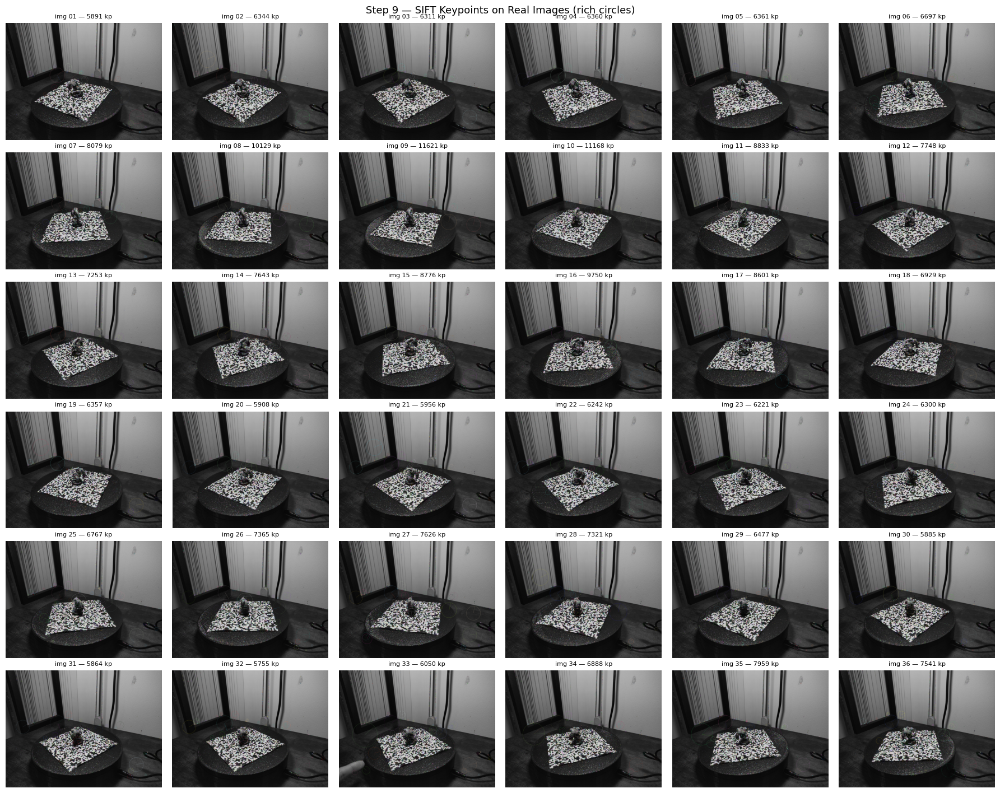

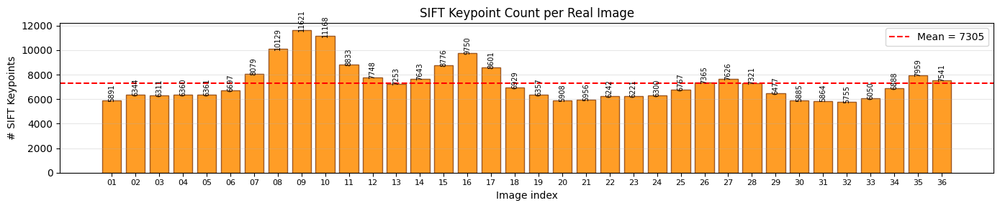

In [18]:
real_kps_all   = []
real_descs_all = []
for gray in real_images_gray:
    kp, desc = sift.detectAndCompute(gray, None)
    real_kps_all.append(kp)
    real_descs_all.append(desc)

real_kp_counts = [len(k) for k in real_kps_all]
print(f"SIFT keypoints per real image — mean: {np.mean(real_kp_counts):.0f}  "
      f"min: {min(real_kp_counts)}  max: {max(real_kp_counts)}")

# ── Contact sheet: rich keypoints overlaid ────────────────────────────────────
COLS = 6
ROWS = int(np.ceil(N_REAL / COLS))
fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3, ROWS * 2.4))
axes = np.array(axes).ravel()
for i, ax in enumerate(axes):
    if i < N_REAL:
        img_kp = cv2.drawKeypoints(
            real_images_gray[i], real_kps_all[i], None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        )
        ax.imshow(img_kp)
        ax.set_title(f"img {i+1:02d} — {real_kp_counts[i]} kp", fontsize=8)
    ax.axis("off")
plt.suptitle("Step 9 — SIFT Keypoints on Real Images (rich circles)", fontsize=13)
plt.tight_layout(); plt.show()

# ── Keypoint count bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
bars = ax.bar(range(N_REAL), real_kp_counts,
              color="darkorange", edgecolor="saddlebrown", alpha=0.85)
for bar, n in zip(bars, real_kp_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            str(n), ha="center", fontsize=7, rotation=90)
ax.set_xticks(range(N_REAL))
ax.set_xticklabels([f"{i+1:02d}" for i in range(N_REAL)], fontsize=8)
ax.set_xlabel("Image index"); ax.set_ylabel("# SIFT Keypoints")
ax.set_title("SIFT Keypoint Count per Real Image")
ax.axhline(np.mean(real_kp_counts), color="red", linestyle="--",
           linewidth=1.5, label=f"Mean = {np.mean(real_kp_counts):.0f}")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()
